# **Image analysis - cell type recognition and count**

In [ ]:
# Packages
import os
import skimage as ski
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import tifffile
import pathlib
import imageio.v3 as iio

<ins>Import an image</ins>

In [7]:
# Import image and take look to parameters
path = r'C:/Users/nmassoulie/Desktop/input_PC_images/Segmented/'

print('Path: ', os.path.exists(path))

img = ski.io.imread(path)
#print(img)
img.shape

Path:  True


(17, 3200, 3200)

<ins>Import a folder</ins>

https://imageio.readthedocs.io/en/stable/examples.html#read-all-images-in-a-folder

In [5]:
# Read image folder
image = []
image_ID = []
for file in pathlib.Path(r'C:/Users/Tibo/Documents/Internship_LCB_Myxococcus_xanthus/Images/Microscopy/Raw/Output_pc/').iterdir():
    if not file.is_file():
        continue
    file_name, file_extension = os.path.splitext(file.name)
    image.append(iio.imread(file))
    image_ID.append(file_name)

# print(image_ID[0], image[0].shape)
img_sp, img_vc = arrays_separation(image[0])


In [6]:
classification(img_sp, img_vc)

MemoryError: 

----

<ins>Functions for image analysis</ins>

In [2]:
# Function separation spore-vc arrays
def arrays_separation(img):

    """
    ## Copy image into two seperate class of arrays (spores and vc)
    ## Condition: normalize image segmentation
    input:
        - Arrays: image
    output:
        - Arrays: spore image
        - Arrays: vc image
    """
    
    # Background correction
    correction = np.ones((17, 3200, 3200))
    img = np.add(img, correction)
    img[img == 2] = 0 # Bkgrd

    # Seperation spore-VC arrays
    img_sp, img_vc = np.copy(img), np.copy(img)
    
    img_sp[img_sp > 1] = 0
    img_vc[img_vc < 2] = 0
    
    return img_sp, img_vc

In [4]:
img_sp, img_vc = arrays_separation(img)
print(img_sp, img_vc)

NameError: name 'img' is not defined

In [3]:
# Function object classification in df
def classification(spores, vegetative):

    """
    ## Take images (spore image, vegetative image):
            - Labels and measures labelled objects (properties)
            - For each image: Creates a mask, computes the volume, surface area and sphericity of each individual object
    ## Conditions:
            - Normalized segmented images
            - Two seperated sub-images (spore image, vegetative image)
    input:
        - Arrays: image (spore image)
        - Arrays: image (vegetative image)
    output:
        - Dataframe: classification objects (properties) in a table
    """
    
    img_grouped = [
        ('spore', spores), 
        ('vc', vegetative)
    ]
    spacing = (1, 0.1621455, 0.1621455)
    voxel_volume = np.prod(spacing)
    results = pd.DataFrame()
        
    for cell_type, i in img_grouped:            
        # Label objects
        labels = ski.measure.label(i)
        objects = ski.measure.regionprops(
            labels, 
            spacing = spacing
        )
            
        # Properties
        for prop in objects:

            # Objects
            label = prop.label
            mask = labels == label
    
            # Volume
            volume = mask.sum() * voxel_volume
            
            # Surface mesh
            verts, faces, _, _ = ski.measure.marching_cubes(mask.astype(float), level=0.5, spacing=spacing)
            surface_area = ski.measure.mesh_surface_area(verts, faces)
                
            # Sphericity
            psi = (np.pi**(1/3) * (6 * volume)**(2/3)) / surface_area

            # Dataframe
            data={
                #"Image.ID": image_ID[image],
                "Label": prop.label,
                "Cell_type": cell_type,
                "Area": prop.area,
                "Volume": volume,
                "Surface_area": surface_area,
                "Sphericity": psi
            }
            d = pd.DataFrame(data, index=[0])
            results = pd.concat([results, d], ignore_index = True)
    
    return results

In [5]:
# 1. Target each image in our output_PC directory
# 2. Seperate image in two sub images - spores and vegetative - and class them according their cell-type
# 3. Classify objects within a dataframe on following properties: 
#            image ID - label - cell type - area (regionprops) - volume - surface area - sphericity
# 4. Discriminate according size of objects (artifacts/noise = false positives)
# 5. 


images = []
df = pd.DataFrame()

for file in pathlib.Path(r'C:/Users/Tibo/Documents/Internship_LCB_Myxococcus_xanthus/Images/Microscopy/Test_spores_count/Segmented/').iterdir():
    if not file.is_file():
        continue
    file_name, file_extension = os.path.splitext(file.name)
    images.append((file_name, iio.imread(file)))
    
    for image in images:
        img_sp, img_vc = arrays_separation(image)
        classification(img_sp, img_vc)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

------------

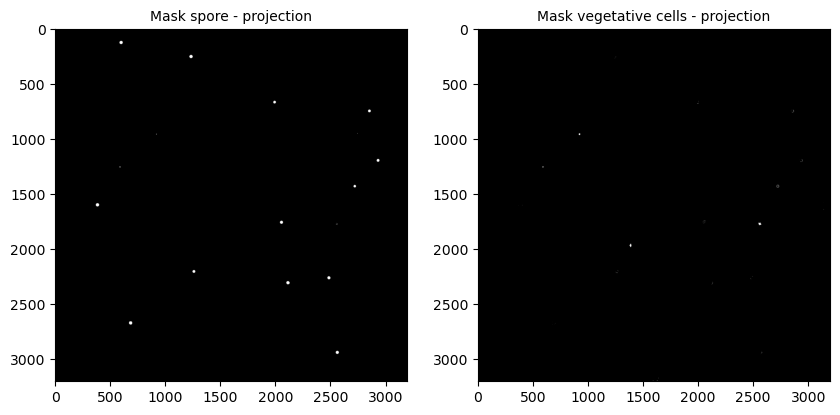

In [4]:
# Ploting first look - projection
img_sp, img_vc = arrays_separation(img)

projection_sp = img_sp.max(axis=0)
projection_vc = img_vc.max(axis=0)

fig, axs = plt.subplots(ncols=2, figsize=(10, 10))
axs[0].set_title('Mask spore - projection', fontsize=10)
axs[0].imshow(projection_sp, cmap='gray')

axs[1].set_title('Mask vegetative cells - projection', fontsize=10)
axs[1].imshow(projection_vc, cmap='gray')

plt.show()

In [ ]:
classification(img_sp, img_vc)
results = results[(results['Area'] > 5)]

print('N_objects: ', len(results['Area']))
results

NameError: name 'results' is not defined

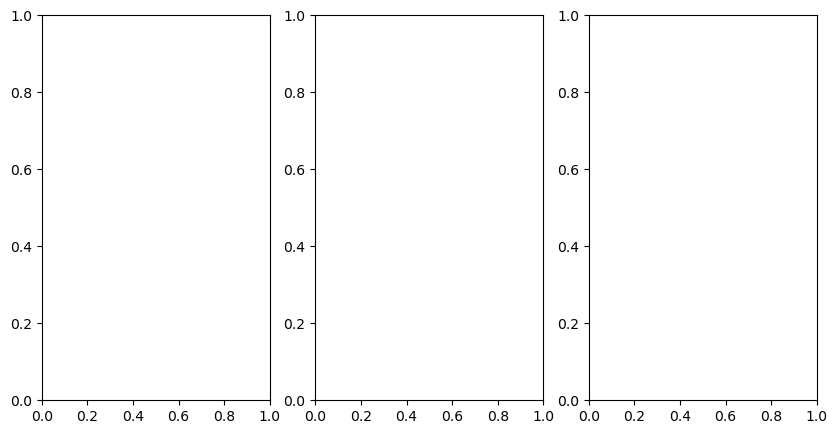

In [4]:
fig, axs = plt.subplots(ncols=3, figsize=(10,5))

axs[0].hist(results['Area'], bins=50, density=True, histtype='barstacked', alpha=1, rwidth=1)
axs[0].hist(results['Volume'], bins=50, density=True, histtype='barstacked', alpha=1, rwidth=0.5)
axs[0].set_title('Area-Volume')

axs[1].hist(results['Surface_area'], bins=50, density=True, histtype='stepfilled', color='r', alpha=0.75)
axs[1].set_title('Surface area')

axs[2].hist(results['Sphericity'], bins=50, density=True, histtype='stepfilled', color='b', alpha=0.75)
axs[2].set_title('Sphericity')

plt.tight_layout

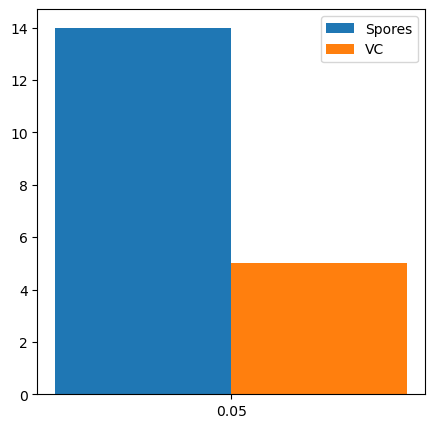

In [48]:
sp = len(results[results['Cell_type'] == 'spore'])
vc = len(results[results['Cell_type'] == 'vc'])

N = 1
width = 0.1       

ind = np.arange(N)

plt.figure(figsize=(5,5))
plt.bar(ind, sp , width, label='Spores')
plt.bar(ind + width, vc, width, label='VC')

plt.xticks(ind + width / 2)

plt.legend(loc='best')
plt.show()
